In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import seaborn as sns
import re, math
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import ConnectionPatch
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from pathlib import Path
from brokenaxes import brokenaxes
import datetime

ROOT = '/root/workspace/vllm-dynamic/scripts'
DATASET_PATH=f'{ROOT}/dataset/e2e'
PDF_PATH=f'{ROOT}/pdf'
line_styles = ['-', '--', '-.', ':', 'solid', 'dashed', 'dashdot', 'dotted', '-', '--', '-.', ':', 'solid', 'dashed', 'dashdot', 'dotted']
markers = ['o', 's', 'D', '^', 'v', 'x', '+', '1', '2', '3', '4', '8', 'p', '*', 'h', 'H', '<', '>', 'd']
hatches = hatches = ['...', '--', '///', '\\\\\\', '+', 'x', 'o', 'O', '.', '*', '0', '1', '2', '3', '4', '5', '6', '7', '8']

In [15]:
def get_data_from_log(model_name, num_prompt, system_names, dataset_paths, output_csv_path):
    # Define metrics to collect
    metrics = {
        'output_throughput': [],
        'mean_ttft': [],
        'p99_ttft': [],
        'mean_tpot': [],
        'p99_tpot': [],
        'mean_itl': [],
        'p99_itl': []
    }
    
    # Compile regex pattern once (fixed syntax error in original)
    pattern = re.compile(
        r"Output token throughput \(tok/s\):\s+(?P<output_throughput>\d+\.\d+).*?"
        r"Mean TTFT \(ms\):\s+(?P<mean_ttft>\d+\.\d+).*?"
        r"P99 TTFT \(ms\):\s+(?P<p99_ttft>\d+\.\d+).*?"
        r"Mean TPOT \(ms\):\s+(?P<mean_tpot>\d+\.\d+).*?"
        r"P99 TPOT \(ms\):\s+(?P<p99_tpot>\d+\.\d+).*?"
        r"Mean ITL \(ms\):\s+(?P<mean_itl>\d+\.\d+).*?"
        r"P99 ITL \(ms\):\s+(?P<p99_itl>\d+\.\d+)",
        re.DOTALL
    )

    for system_name, dataset_path in zip(system_names, dataset_paths):
        log_content = Path(dataset_path).read_text()
        matches = pattern.finditer(log_content)  # Using finditer for efficiency
        
        if not matches:
            print(f"No matches found in log file: {dataset_path}")
            continue

        # Temporary storage for current dataset values
        current_values = {key: [] for key in metrics.keys()}
        
        for match in matches:
            for metric in current_values.keys():
                current_values[metric].append(float(match.group(metric)))
        
        # Calculate averages and store
        for metric, values in current_values.items():
            avg = sum(values) / len(values) if values else 0.0
            if system_name == 'hcache':
                if 'tpot' in metric or 'itl' in metric or 'ttft' in metric:
                    metrics[metric].append(min(values))
                else: metrics[metric].append(max(values))
            else:  metrics[metric].append(avg)
        
        # Print results
        # print(f"\nSystem: {system_name}, model_name: {model_name}")
        # print( f"dataset_path: {dataset_path}")
        # for metric, avg in zip(current_values.keys(), metrics.values()):
        #     print(f"Avg {metric.replace('_', ' ').title()}: {avg[-1]:.2f} {'tok/s' if metric == 'output_throughput' else 'ms'}")

    # Create DataFrame and save to CSV
    df = pd.DataFrame({
        'model_name': [model_name] * len(system_names),
        'num_prompt': [num_prompt] * len(system_names),
        'system_name': system_names,
        **{f'avg_{k}': v for k, v in metrics.items()}
    })

    # print(f"\nDataFrame:\n{df}")
    
    # Save DataFrame to CSV,追加
    output_csv_path = Path(output_csv_path)
    if output_csv_path.exists():
        df.to_csv(output_csv_path, mode='a', header=False, index=False)
    else:
        df.to_csv(output_csv_path, index=False)
    return df

In [5]:
system_names = ['vllm-recompute', 'vllm-swap', 'hcache', 'ellm']
system_labels = ['Recompute', 'Swap', 'HCache', 'eLLM']
model_names = ['meta-llama_Llama-2-13b-chat-hf', 'meta-llama_Llama-2-70b-chat-hf']
# num_promts = 3024
num_promts = 184
data_name = 'paper_assistant'
now = datetime.datetime.now()
current_date = now.strftime("%Y-%m-%d")
output_csv_path = f'{DATASET_PATH}/e2e_results_{data_name}_{current_date}.csv'
for model_name in model_names:
    dataset_paths = []
    gpu_num = 1 if '13b' in model_name else 4
    for system_name in system_names:
        if system_name == 'vllm-swap':
            dataset_path  = f'{DATASET_PATH}/{system_name}/{data_name}/{model_name}_client_{num_promts}_swap_{gpu_num}gpu.log'
        else:
            dataset_path  = f'{DATASET_PATH}/{system_name}/{data_name}/{model_name}_client_{num_promts}_recompute_{gpu_num}gpu.log'
        dataset_paths.append(dataset_path)    
    # get_data_from_log(model_name, system_names, dataset_paths, output_csv_path)    

In [52]:
def plot_figure(metric, y_metric, model_names, model_labels):
    df = pd.read_csv(output_csv_path) 
    df = df.groupby(['model_name', 'system_name']).mean().reset_index()
    if 'ttft' in metric:
        df[f'{metric}'] = df[f'{metric}'] / 1000   

    fig = plt.figure(figsize=(3, 2), dpi=120)
    x = np.arange(len(model_names))
    width = 0.15
    # if metric == 'avg_p99_tpot':
    #     ax = brokenaxes(ylims=((0, 500), (3700, 5700)), hspace=0.1)
    #     for sub_ax in ax.axs:
    #         sub_ax.set_xticks(x + width * (len(system_names) - 1) / 2)
    #         sub_ax.set_xticklabels(model_labels)
    # else:
    ax = fig.add_subplot(111)
    ax.set_xticks(x + width * (len(system_names) - 1) / 2)
    ax.set_xticklabels(model_labels)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    for i, system_name in enumerate(system_names):
        if i < 2: 
            ax.bar(x + i * width, 
                  df[f'{metric}'][df['system_name'] == system_name], 
                  width=width, 
                  label=system_labels[i], 
                  color='white', 
                  hatch=hatches[i], 
                  edgecolor='black', 
                  zorder=10)
        else: 
            ax.bar(x + i * width, 
                  df[f'{metric}'][df['system_name'] == system_name], 
                  width=width, 
                  label=system_labels[i], 
                  color=plt.cm.tab20b((i-1)/5), 
                  hatch=hatches[i], 
                  zorder=10, 
                  edgecolor='black',
                  linewidth=0.5)
        # 将真实值添加到bar上
        # for j, model_name in enumerate(model_names):
        #     value = df[f'{metric}'][(df['system_name'] == system_name) & (df['model_name'] == model_name)].values[0]
        #     if metric == 'avg_p99_tpot':
        #         value = value / 1000
        #     ax.text(x[j] + i * width, value + 0.06, f'{value:.0f}', ha='center', va='bottom', fontsize=8, color='black', rotation=15)
            
    for i, model_name in enumerate(model_names):
        # 在bar上添加文本，用最小值进行normalization
        baseline = df[f'{metric}'][df['model_name'] == model_name].min()
        print(f'baseline: {baseline}')
        for j, system_name in enumerate(system_names): 
            value = df[f'{metric}'][(df['system_name'] == system_name) & (df['model_name'] == model_name)].values[0]
            norm_value = value/baseline
            if metric == 'avg_p99_tpot':
                value = value / 1000
            ax.text(x[i] + j * width, value + 0.05, f'{norm_value:.2f}', ha='center', va='bottom', fontsize=10, color='black', rotation=60)    

    ax.set_ylabel(y_metric)
    
    # 只有非brokenaxes时才设置ylim
    if metric != 'avg_p99_tpot':
        ax.set_ylim(0, 1.7 * df[f'{metric}'].max())
    ax.grid(True, axis='y', linestyle='--', linewidth=0.3, zorder=-10)
    ax.legend(loc=(0.2, 0.73), ncol=2, framealpha=1, frameon=False, columnspacing=0.3, labelspacing=0.2, handlelength=1, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)
    plt.savefig(f'{PDF_PATH}/e2e_{metric}_{data_name}.pdf', bbox_inches='tight')

baseline: 257.66
baseline: 167.80999999999997
Figure for avg_output_throughput saved.
baseline: 146.5131383333333
baseline: 68.367254
Figure for avg_mean_ttft saved.
baseline: 64.0
baseline: 190.09
Figure for avg_mean_tpot saved.


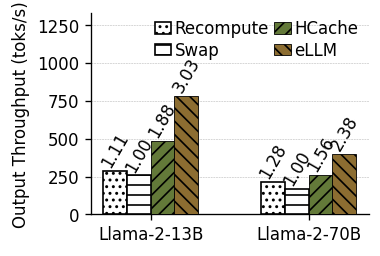

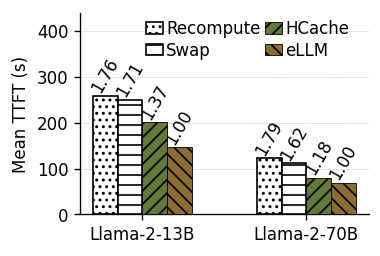

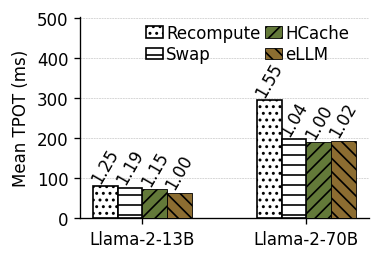

In [64]:
metrics = ['avg_output_throughput', 'avg_mean_ttft',  'avg_mean_tpot']
y_metrics = ['Output Throughput (toks/s)', 'Mean TTFT (s)', 'Mean TPOT (ms)']
model_labels = ['Llama-2-13B', 'Llama-2-70B']
for metric, y_metric in zip(metrics, y_metrics):
    plot_figure(metric, y_metric, model_names, model_labels)
    print(f"Figure for {metric} saved.")

# Plot performance of various request loads

In [196]:
def plot_various_loads(file_path, metric, metric_label, x_labels, model_name):
    df = pd.read_csv(file_path)
    df = df[df['model_name'] == model_name]
    df = df.groupby(['model_name', 'num_prompt', 'system_name']).mean().reset_index()
    # print(f"DataFrame:\n{df}")
    fig = plt.figure(figsize=(3, 2), dpi=120)
    ax = fig.add_subplot(111)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    if 'sharegpt' in file_path:
        df['num_prompt_label']=df['num_prompt'].apply(lambda x: f'{x//1000}k')
    else:
        df['num_prompt_label']=df['num_prompt'].apply(lambda x: f'{x}')    
    for i, system_name in enumerate(system_names):
        system_df = df[df['system_name'] == system_name]
        if metric == 'avg_mean_ttft':
            system_df[metric] = system_df[metric] / 1000
        # if metric == 'avg_output_throughput':
        #     # 将吞吐量按照大小排序
        #     system_df = system_df.sort_values(by=[metric], ascending=True)
        ax.plot(system_df['num_prompt_label'], system_df[metric], marker=markers[i], linestyle=line_styles[i], color=plt.cm.tab20b(i/5), label=system_labels[i], zorder=10, markeredgewidth=1.5, markerfacecolor="none", markeredgecolor=plt.cm.tab20b(i/5))
    ax.set_xlabel('Request loads')
    ax.set_ylabel(metric_label)
    if metric == 'avg_mean_ttft': ax.set_ylim(0, 1.5 * df[metric].max()/1000)
    else: ax.set_ylim(0, 1.5 * df[metric].max())
    # ax.set_xticks(np.arange(len(x_labels)))
    # ax.set_xticks([1000, 2000, 3000, 4000,5000])
    ax.set_xticklabels(x_labels)
    ax.grid(True, axis='y', linestyle='--', linewidth=0.3, zorder=-10)
    ax.legend(loc=(0.05, 0.73), ncol=2, framealpha=1, frameon=False, columnspacing=0.3, labelspacing=0.2, handlelength=1.5, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)
    plt.savefig(f'{PDF_PATH}/various_loads_{metric}_{data_name}.pdf', bbox_inches='tight')

avg_prompts: [3.066666666666667, 5.533333333333333, 7.733333333333333, 10.6, 13.116666666666667]


/tmp/ipykernel_88193/3634816712.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels)
/tmp/ipykernel_88193/3634816712.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  system_df[metric] = system_df[metric] / 1000
/tmp/ipykernel_88193/3634816712.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels)
/tmp/ipykernel_88193/3634816712.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels)


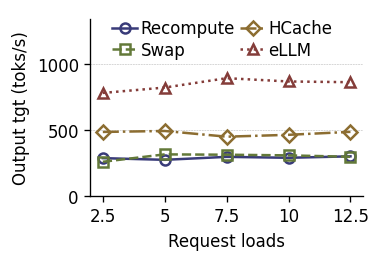

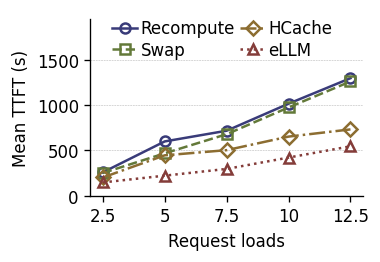

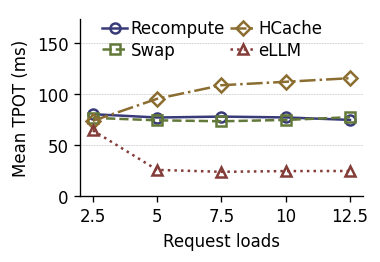

In [204]:
system_names = ['vllm-recompute', 'vllm-swap', 'hcache', 'ellm']
system_labels = ['Recompute', 'Swap', 'HCache', 'eLLM']
model_names = ['meta-llama_Llama-2-13b-chat-hf']
# num_promts = 3024
data_name = 'sharegpt'
num_prompts = [787, 1553, 3024, 4541, 6069]
x_labels = [12.5, 25, 50, 75, 100]
data_name = 'paper_assistant'
num_prompts = [184, 332, 464, 636, 787]
x_labels = [2.5, 5, 7.5, 10, 12.5]
avg_prompts = [item/60 for item in num_prompts]
print(f"avg_prompts: {avg_prompts}")
now = datetime.datetime.now()
current_date = now.strftime("%Y-%m-%d")
# current_date = '2025-04-27'
output_csv_path = f'{DATASET_PATH}/e2e_results_various_rates_{data_name}_{current_date}.csv'
plot_figure = True

if not plot_figure:
    if Path(output_csv_path).exists():
        Path(output_csv_path).unlink()
        # print(f"Deleted existing file: {output_csv_path}")
    for model_name in model_names:
        gpu_num = 1 if '13b' in model_name else 4
        for num_prompt in num_prompts:    
            dataset_paths = []
            for system_name in system_names:
                if system_name == 'vllm-swap':
                    dataset_path  = f'{DATASET_PATH}/{system_name}/{data_name}/{model_name}_client_{num_prompt}_swap_{gpu_num}gpu.log'
                else:
                    dataset_path  = f'{DATASET_PATH}/{system_name}/{data_name}/{model_name}_client_{num_prompt}_recompute_{gpu_num}gpu.log'
                # print(f"dataset_path: {dataset_path}")
                dataset_paths.append(dataset_path)    
            get_data_from_log(model_name, num_prompt, system_names, dataset_paths, output_csv_path)
else:            
    file_path = f'{DATASET_PATH}/e2e_results_various_rates_{data_name}_{current_date}.csv'
    metrics = ['avg_output_throughput', 'avg_mean_ttft',  'avg_mean_tpot']
    y_metrics = ['Output Throughput (toks/s)', 'Mean TTFT (s)', 'Mean TPOT (ms)']
    plot_various_loads(file_path, 'avg_output_throughput', 'Output tgt (toks/s)', x_labels, model_names[0])
    plot_various_loads(file_path, 'avg_mean_ttft', 'Mean TTFT (s)', x_labels, model_names[0])
    plot_various_loads(file_path, 'avg_mean_tpot', 'Mean TPOT (ms)', x_labels, model_names[0])